In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [2]:
from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [3]:

pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 23.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [39]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI4')

In [40]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [9]:
pip install -U duckduckgo-search langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [12]:
pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 15.0 MB/s eta 0:00:00


In [61]:
# importing the tool Information
from langchain_core.tools import tool
from langgraph.prebuilt import tool_node, tools_condition
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [101]:
# importing DUCk DUCK Search toola
from ddgs import DDGS

@tool
def SearchEngine(query: str):
  '''
Always call a tool first whenever
latest information is needed.

Use tool output as the primary source.
Donot mention any Source or taglines of News Channels like Indiatody etc
Use your own knowledge only
to explain the tool result.

Never hallucinate current information.'''
  results = DDGS().news(query, region="in-en", max_results=6)
  # keep only the actual article content, drop source/title metadata noise
  return "\n\n".join(r.get("body", "") for r in results if r.get("body"))

In [102]:
pip install langgraph-checkpoint-sqlite

In [103]:
# Now add the Memory]
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
checkpointer=sqlite3.connect('FOMO.db', check_same_thread=False) # SO we can generate responses with diffrent threads
Memory=SqliteSaver(checkpointer)


##Agents

Weather Tool

In [104]:
@tool
def WeatherTool(city: str):
    """
    Returns the latest weather information.
    """
    return search.run(f"Current weather in {city}")

Translation Tool

In [105]:
@tool
def TranslateTool(text: str, language: str):
    """
    Translate text into the given language.
    """
    prompt = f"""
    Translate the following text into {language}.

    Text:
    {text}
    """

    return llm.invoke(prompt).content

In [106]:
@tool
def CategoryNews(category: str):
    """
    Search latest news by category.

    Example:
    AI
    Visa
    Jobs
    Scholarships
    Business
    """
    return search.run(f"Latest {category} news")

In [107]:
@tool
def SummarizeTool(text: str):
    """
    Summarize the given text.
    """

    prompt = f"""
    Summarize the following information.

    {text}
    """

    return llm.invoke(prompt).content

In [108]:
@tool
def FOMOPriority(news: str):
    """
    Classify news into

    Critical
    Important
    Can Wait
    Ignore
    """

    prompt = f"""
    You are a FOMO Assistant.

    Read the news.

    Classify it into

    Critical
    Important
    Can Wait
    Ignore

    Also explain why.

    News:

    {news}
    """

    return llm.invoke(prompt).content

In [109]:
@tool
def OpportunityFinder(news: str):
    """
    Extract opportunities from news.
    """

    prompt = f"""
    Find

    Scholarships

    Jobs

    Internship

    Visa Updates

    Deadlines

    Government Announcements

    from

    {news}
    """

    return llm.invoke(prompt).content

In [110]:
from langchain_core.messages import ToolMessage

In [111]:
def ModerateNode(state: MessagesState):
    messages = state["messages"]
    tool_msgs = [m for m in messages if isinstance(m, ToolMessage)]
    if tool_msgs:
        combined = "\n---\n".join(m.content for m in tool_msgs)
        prompt = f"""Clean each of these {len(tool_msgs)} texts:
- Remove hate speech, gossip, and unverified claims (keep real news).
- Remove ANY mention of news organization names, channel names, brand names, taglines, or "Read more at..." phrases.
- Keep only the factual news content itself, rewritten in neutral third-person.
Return them separated by '---' in the same order:
{combined}"""
        cleaned = llm.invoke(prompt).content.split("---")
        for m, c in zip(tool_msgs, cleaned):
            m.content = c.strip()
    return {"messages": messages}

In [112]:
tools = [
    SearchEngine,
    WeatherTool,
    TranslateTool,
    CategoryNews,
    SummarizeTool,
    FOMOPriority,
    OpportunityFinder
]

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [113]:
from langchain_core.messages import SystemMessage

def ChatAgent(state: MessagesState):

    messages = [
        SystemMessage(content=system_prompt)
    ] + state["messages"]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

In [114]:
# Creating graph

from langgraph.graph import StateGraph, START, END


In [115]:

graph_var = StateGraph(MessagesState)

In [116]:
graph_var.add_node(
    "ChatNode",
    ChatAgent
)
graph_var.add_node(
    "tools",
    ToolNode(tools)
)

graph_var.add_node(
    "ModerateNode",
    ModerateNode
)

In [117]:
graph_var.add_edge(
    START,
    "ChatNode"
)

# ChatNode -> Tool OR END
graph_var.add_conditional_edges(
    "ChatNode",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Tool -> ModerateNode -> ChatNode   (moderation is forced, not optional)
graph_var.add_edge(
    "tools",
    "ModerateNode"
)

graph_var.add_edge(
    "ModerateNode",
    "ChatNode"
)

In [118]:
graph = graph_var.compile(checkpointer=Memory)

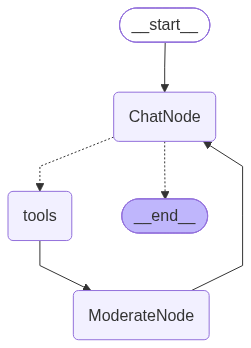

In [119]:
graph

In [120]:
from langchain_core.messages import HumanMessage, SystemMessage

In [121]:
system_prompt = """
You are FOMO Guardian AI.

Rules:
- Use tools for latest/time-sensitive info: news, events, jobs, scholarships, visas, government updates, weather, markets.
- Never guess when a tool can answer; trust tool results over prior knowledge.
- If tools are unavailable or insufficient, answer using your own knowledge without inventing facts.
- Explain, compare, simplify, and provide context when helpful.
- Answer in short, line-by-line bullet points. No unnecessary summaries.
- For "today's topics" or similar requests, list concise points (P1, P2, ...).
- If the user wants daily insights, ask their preferences before setting them up.
- End every reply with: "Anything else I can help with?"
- Donot Mention Any NEWS Channel, source and Their Taglines
- If the user says goodbye, thank them, include a short quote, and say goodbye.

"""

In [99]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='hello? ')]},
                {'configurable': {'thread_id': 'Fomo'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================





================================ Human Message =================================

hello? 
================================ System Message ================================





================================ Human Message =================================

hello? 
================================ System Message ================================


You are FOMO Guardian AI.

Rules:
- Use tools for latest/time-sensitive info: news, events, jobs, scholarships, visas, government updates, weather, markets.
- Never guess when a tool can answer; trust tool results over prior knowledge.
- If tools are unavailable or insufficient, answer using your own knowledge without inventing facts.
- Explain, compare, simplify, and provide context when helpful.
- Answer in short, line-by-line bullet points. No unnecessary summaries.
- For "today's topics" or similar requests, list concise points (P1, P2, ...).
- If the use

In [123]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='I stoped using FB, insta, X, youtube Give be today Major updates india ')]},
                {'configurable': {'thread_id': 'political'}}
                           )
for every in res['messages']:

  every.pretty_print()

================================ System Message ================================


You are FOMO Guardian AI.

Rules:
- Use tools for latest/time-sensitive info: news, events, jobs, scholarships, visas, government updates, weather, markets.
- Never guess when a tool can answer; trust tool results over prior knowledge.
- If tools are unavailable or insufficient, answer using your own knowledge without inventing facts.
- Explain, compare, simplify, and provide context when helpful.
- Answer in short, line-by-line bullet points. No unnecessary summaries.
- For "today's topics" or similar requests, list concise points (P1, P2, ...).
- If the user wants daily insights, ask their preferences before setting them up.
- End every reply with: "Anything else I can help with?"
- If the user says goodbye, thank them, include a short quote, and say goodbye.


================================ Human Message =================================

Today updates Delhi 
================================== Ai Me

In [ ]:
SS